# Auction Insights: An EDA of IPL 2025 Player Bidding Trends
### Exploratory Data Analysis Project
This notebook performs a comprehensive exploratory data analysis of IPL 2025 auction data to understand bidding behavior, team strategies, and player demand.

## 1. Import Libraries
- Used to load required libraries like pandas, numpy, matplotlib, seaborn
- Helps in data manipulation, analysis, and visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

## 2. Load Dataset
- Reads dataset into a DataFrame for processing
- Makes data ready for analysis and visualization

In [2]:
df=pd.read_csv("ipl_2025_auction_players.csv")
df.head()

,Players,Team,Type,Base,Sold
0,Virat Kohli,RCB,BAT,-,21.00
1,Rajat Patidar,RCB,BAT,-,11.00
2,Yash Dayal,RCB,BOWL,-,5.00
3,Jasprit Bumrah,MI,BOWL,-,18.00
4,Suryakumar Yadav,MI,BAT,-,16.35


## 3. Dataset Shape
- Shows structure, columns, and data types
- Helps identify missing values and data quality

In [3]:
df.shape

(623, 5)

In [4]:
df.columns

Index(['Players', 'Team', 'Type', 'Base', 'Sold'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Players  623 non-null    object
 1   Team     623 non-null    object
 2   Type     623 non-null    object
 3   Base     623 non-null    object
 4   Sold     623 non-null    object
dtypes: object(5)
memory usage: 24.5+ KB


## 4. Statistical Summary

In [6]:
df.describe()

,Players,Team,Type,Base,Sold
count,623,623,623,623,623
unique,620,11,4,9,72
top,Daryl Mitchell,-,BOWL,0.30,TBA
freq,2,395,216,322,293


In [7]:
df.isnull().sum()

Players    0
Team       0
Type       0
Base       0
Sold       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2)

## 5. Data Cleaning
- Removes null values or incorrect data
- Ensures dataset is accurate and usable

In [9]:
df.drop_duplicates(inplace=True)
df['Sold']=pd.to_numeric(df['Sold'],errors='coerce')
df.head()

,Players,Team,Type,Base,Sold
0,Virat Kohli,RCB,BAT,-,21.00
1,Rajat Patidar,RCB,BAT,-,11.00
2,Yash Dayal,RCB,BOWL,-,5.00
3,Jasprit Bumrah,MI,BOWL,-,18.00
4,Suryakumar Yadav,MI,BAT,-,16.35


## 6. Feature Engineering
- Helps understand meaning of each column
- Important for correct analysis and insights

In [10]:
df['Price_Category']=pd.cut(df['Sold'],
bins=[0,2,5,10,25],
labels=['Low','Medium','High','Premium'])
df.head()

,Players,Team,Type,Base,Sold,Price_Category
0,Virat Kohli,RCB,BAT,-,21.00,Premium
1,Rajat Patidar,RCB,BAT,-,11.00,Premium
2,Yash Dayal,RCB,BOWL,-,5.00,Medium
3,Jasprit Bumrah,MI,BOWL,-,18.00,Premium
4,Suryakumar Yadav,MI,BAT,-,16.35,Premium


## 7. Player Type Distribution
- Shows count of each player type
- Helps understand dataset composition

C:\Users\krish\AppData\Local\Temp\ipykernel_13384\1429891460.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Type', palette='coolwarm')


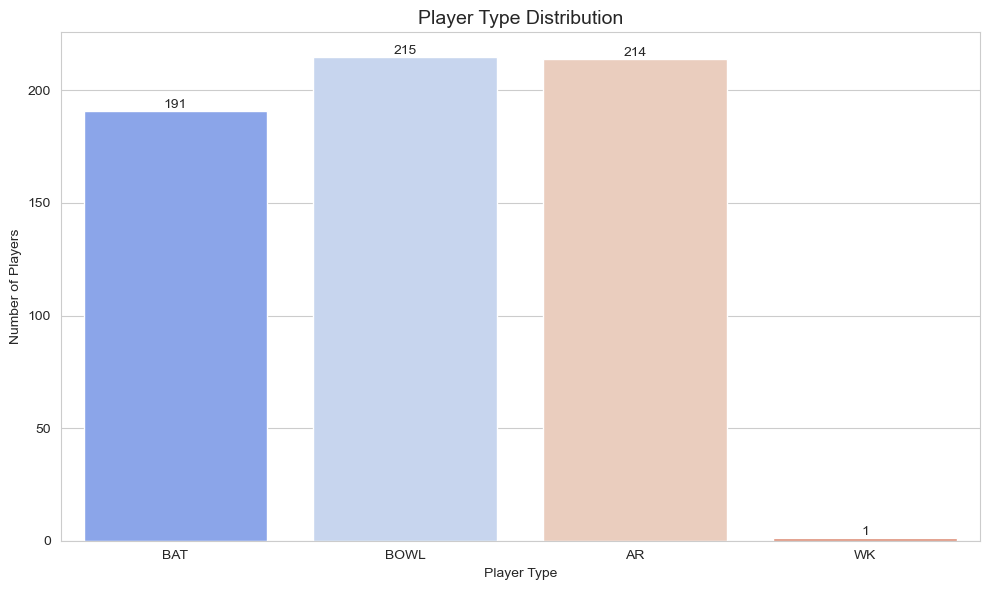

In [11]:
sns.set_style('whitegrid')

ax = sns.countplot(data=df, x='Type', palette='coolwarm')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Player Type Distribution", fontsize=14)
plt.xlabel("Player Type")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

## 8. Team Distribution
- Displays number of players per team
- Useful to compare team squad sizes

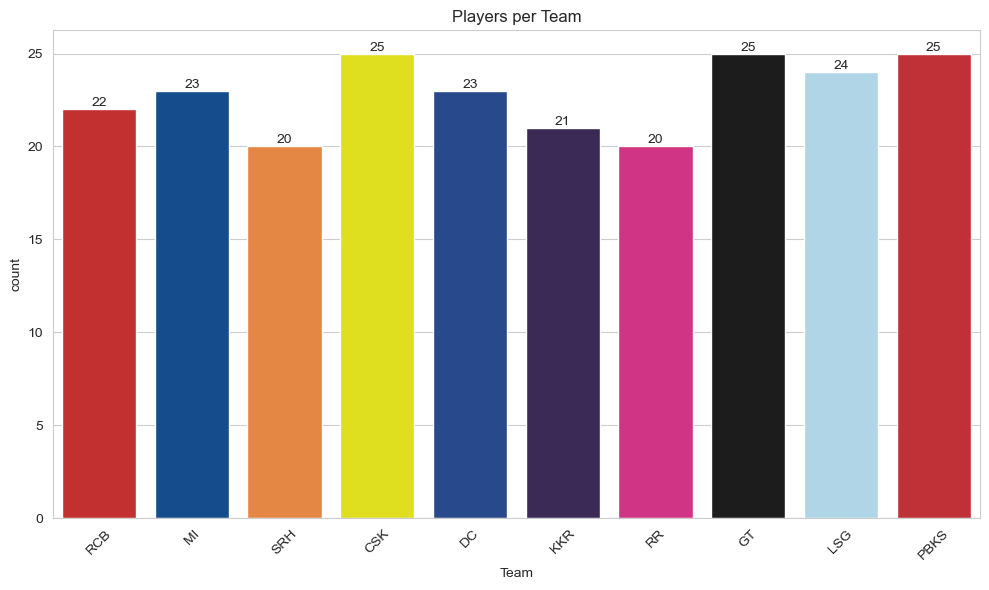

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df[df['Team'] != '-']

team_colors = {
    'MI': '#004BA0',
    'CSK': '#FFFF00',
    'RCB': '#DA1818',
    'KKR': '#3A225D',
    'DC': '#17449B',
    'SRH': '#FF822A',
    'PBKS': '#D71920',
    'RR': '#EA1A85',
    'GT': '#1C1C1C',
    'LSG': '#A7D8F0'
}

plt.figure(figsize=(10,6))

ax = sns.countplot(data=df, x='Team', hue='Team',
                   palette=team_colors, legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.title("Players per Team")
plt.tight_layout()
plt.show()

## 9. Auction Price Distribution
- Displays how player prices are spread
- Helps detect skewness and outliers

C:\Users\krish\AppData\Local\Temp\ipykernel_13384\2356429105.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Sold'], bins=30, kde=True, palette='viridis')


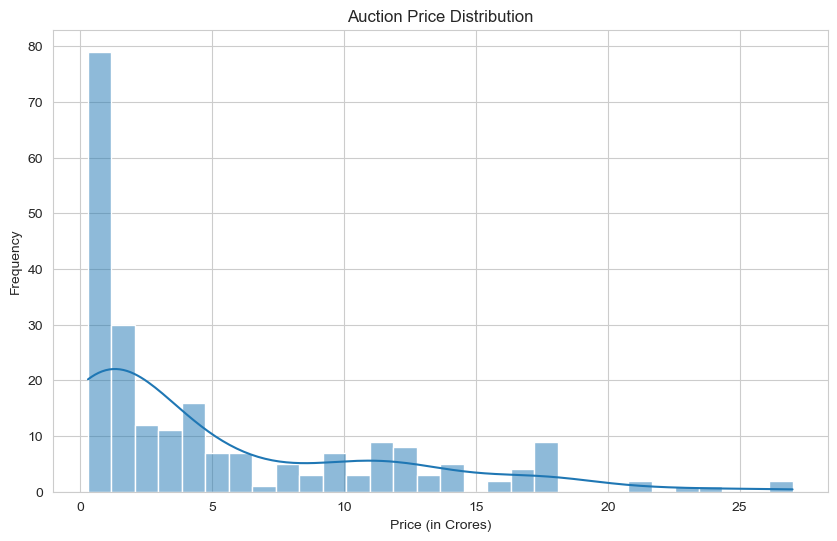

In [13]:
sns.histplot(df['Sold'], bins=30, kde=True, palette='viridis')

plt.title("Auction Price Distribution")
plt.xlabel("Price (in Crores)")
plt.ylabel("Frequency")

plt.show()

## 10. Top 10 Expensive Players
- Identifies highest paid players
- Highlights star or high-demand players

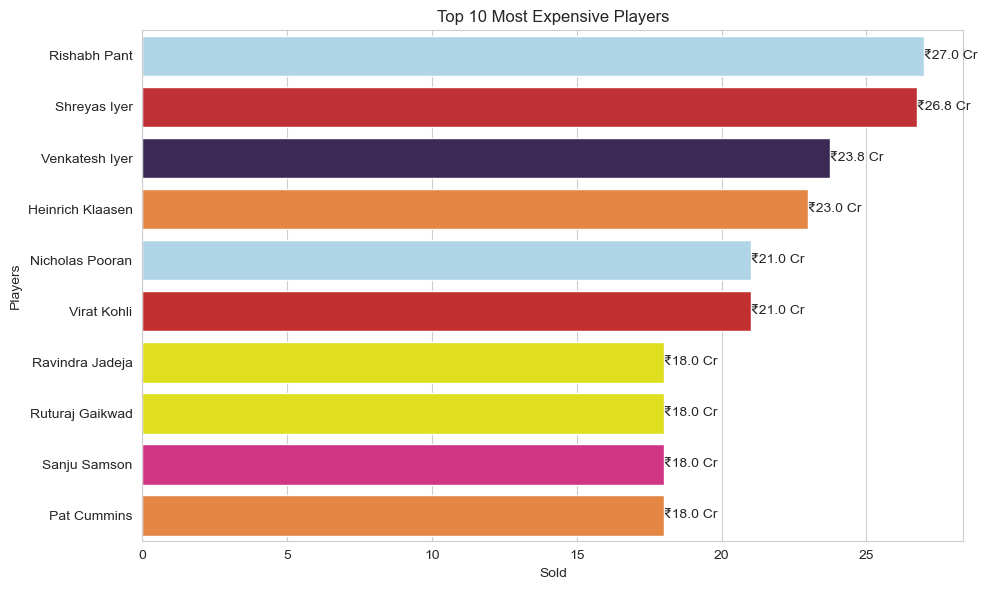

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

team_colors = {
    'MI': '#004BA0',
    'CSK': '#FFFF00',
    'RCB': '#DA1818',
    'KKR': '#3A225D',
    'DC': '#17449B',
    'SRH': '#FF822A',
    'PBKS': '#D71920',
    'RR': '#EA1A85',
    'GT': '#1C1C1C',
    'LSG': '#A7D8F0'
}

top10 = df.sort_values(by='Sold', ascending=False).head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=top10, x='Sold', y='Players',
                 hue='Team', palette=team_colors, dodge=False)

ax.legend_.remove()

for i, v in enumerate(top10['Sold']):
    ax.text(v, i, f'₹{v:.1f} Cr', va='center')

plt.title("Top 10 Most Expensive Players")
plt.tight_layout()
plt.show()

## 11. Team Spending Analysis
- Shows average spending per player by team
- Helps compare team investment strategies

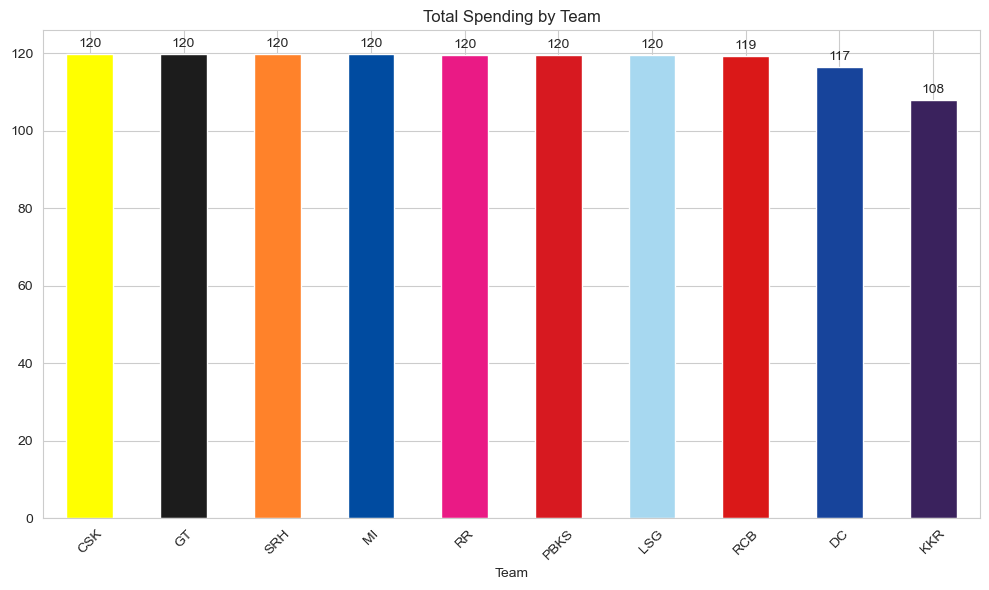

In [15]:
import matplotlib.pyplot as plt

team_colors = {
    'MI': '#004BA0',
    'CSK': '#FFFF00',
    'RCB': '#DA1818',
    'KKR': '#3A225D',
    'DC': '#17449B',
    'SRH': '#FF822A',
    'PBKS': '#D71920',
    'RR': '#EA1A85',
    'GT': '#1C1C1C',
    'LSG': '#A7D8F0'
}

team_spend = df.groupby('Team')['Sold'].sum().sort_values(ascending=False)

bar_colors = [team_colors.get(team, '#333333') for team in team_spend.index]

ax = team_spend.plot(kind='bar', color=bar_colors, figsize=(10,6))

for i, v in enumerate(team_spend):
    ax.text(i, v + 1, f'{v:.0f}', ha='center', va='bottom')

plt.title("Total Spending by Team")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Average Player Price by Team
- Shows average spending per player by team
- Helps compare team investment strategies

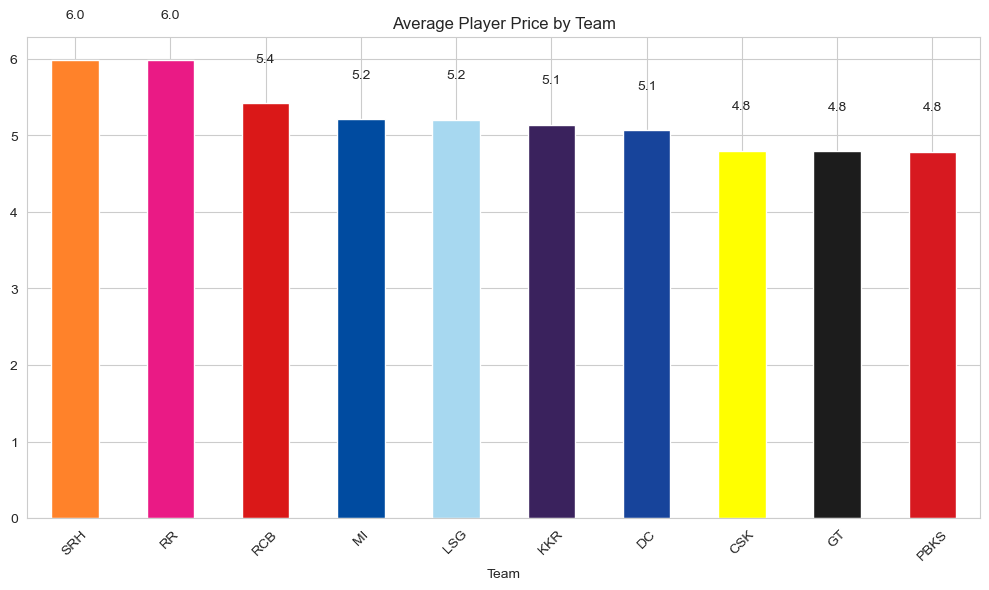

In [16]:
import matplotlib.pyplot as plt

team_colors = {
    'MI': '#004BA0',
    'CSK': '#FFFF00',
    'RCB': '#DA1818',
    'KKR': '#3A225D',
    'DC': '#17449B',
    'SRH': '#FF822A',
    'PBKS': '#D71920',
    'RR': '#EA1A85',
    'GT': '#1C1C1C',
    'LSG': '#A7D8F0'
}

avg_price = df.groupby('Team')['Sold'].mean().sort_values(ascending=False)

bar_colors = [team_colors.get(team, '#333333') for team in avg_price.index]

ax = avg_price.plot(kind='bar', color=bar_colors, figsize=(10,6))

for i, v in enumerate(avg_price):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom')

plt.title("Average Player Price by Team")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Role vs Price Boxplot
- Shows price distribution by player role
- Helps compare median and outliers

C:\Users\krish\AppData\Local\Temp\ipykernel_13384\595084884.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


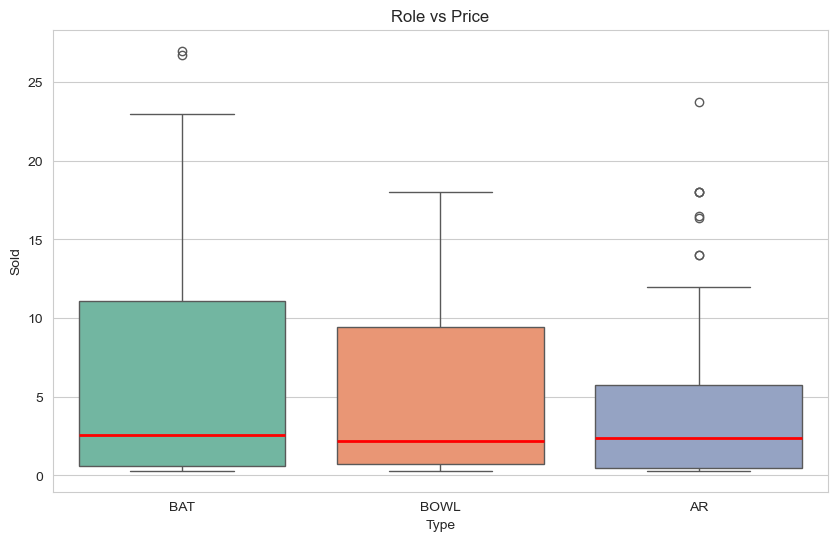

In [17]:
sns.boxplot(
    data=df, x='Type', y='Sold',
    palette='Set2',
    medianprops={'color': 'red', 'linewidth': 2}
)

plt.title("Role vs Price")
plt.show()

## 14. Price Category Distribution
- Shows relationship between price and performance
- Helps check if expensive players perform better

C:\Users\krish\AppData\Local\Temp\ipykernel_13384\976585857.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Price_Category', palette='Set2')


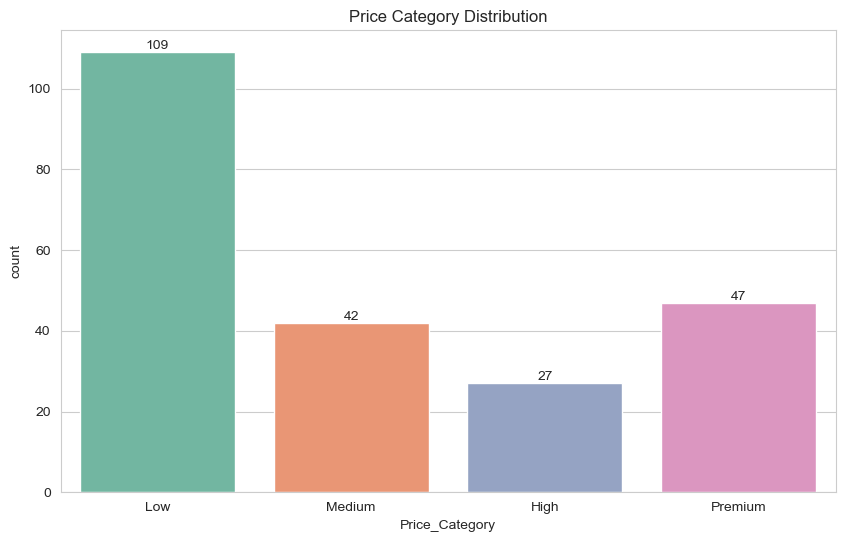

In [18]:
ax = sns.countplot(data=df, x='Price_Category', palette='Set2')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Price Category Distribution")
plt.show()

## 15. Team Strategy Heatmap
- Shows relation between team and player type
- Helps identify team composition strategy

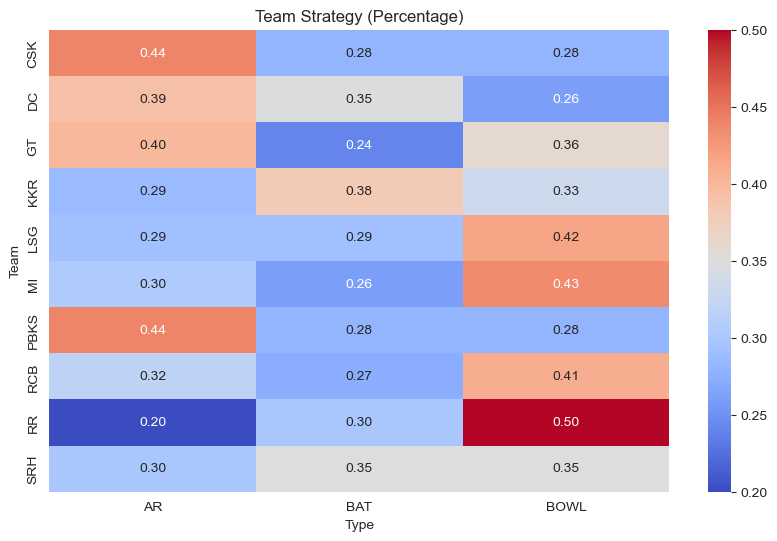

In [19]:
strategy = pd.crosstab(df['Team'], df['Type'], normalize='index')

sns.heatmap(strategy, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Team Strategy (Percentage)")
plt.show()

## Conclusion
The analysis highlights important IPL auction trends including pricing patterns, team spending strategies, and player demand distribution. EDA helps understand how franchises allocate budgets and prioritize player roles.